In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/!_gradient


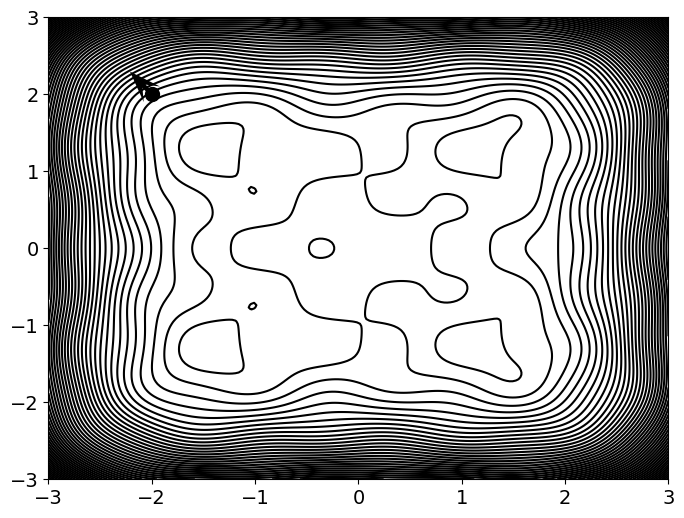

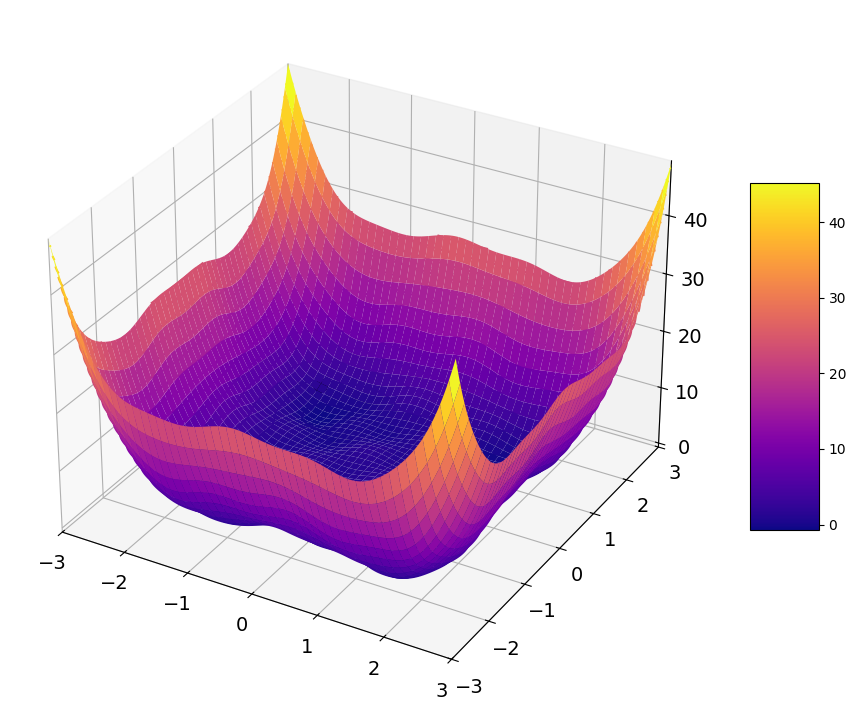

In [46]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

# Define a scaled-down function with a cross-shaped rugged valley using PyTorch
def f(x, y):
    return 0.5 * ((x**2 - 2)**2 + (y**2 - 2)**2) - 2.5 * torch.exp(-0.5 * (x**2 + y**2)) + 0.5 * torch.sin(5 * x) * torch.cos(5 * y)

# Function to compute the gradient using PyTorch
def compute_gradient(x, y):
    # Convert x and y to PyTorch tensors with float32 dtype and enable gradient computation
    x_tensor = torch.tensor(x, dtype=torch.float32, requires_grad=True)
    y_tensor = torch.tensor(y, dtype=torch.float32, requires_grad=True)
    
    # Compute the function value
    z = f(x_tensor, y_tensor)
    
    # Compute the gradients
    z.backward()
    return x_tensor.grad.item(), y_tensor.grad.item()

# Create a grid of points
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
x, y = np.meshgrid(x, y)
z = f(torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)).numpy()  # Compute the function values over the grid

# Define the points at which to visualize the gradient and new point on the surface
x0, y0 = -2, 2
new_x, new_y = -1.8, 1.8
z0 = f(torch.tensor(x0, dtype=torch.float32), torch.tensor(y0, dtype=torch.float32)).item()
new_z = f(torch.tensor(new_x, dtype=torch.float32), torch.tensor(new_y, dtype=torch.float32)).item()
grad = compute_gradient(x0, y0)  # Compute the gradient using PyTorch

# Define the color palette
color_point = "#000000"  # Black for the point to make it distinct
color_arrow = "#000000"  # Solid black for the arrow for contrast

# Create the 2D contour plot with a monochromatic palette
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the contour lines in grayscale (no colors)
contour = ax.contour(x, y, z, levels=50, colors='black')  # Set contour lines to black

# Plot the gradient vector at the point (x0, y0) with a longer arrow
ax.quiver(x0, y0, grad[0], grad[1], color=color_arrow, angles='xy', scale_units='xy', scale=30, linewidth=2.5, headwidth=5, headlength=7)

# Highlight the point on the contour using the color black
ax.scatter(x0, y0, color=color_point, s=100)

# Remove axis labels, keep ticks and axes
ax.tick_params(axis='both', which='major', labelsize=14)

# Save the 2D contour plot
output_path_contour = Path(OUTPUT_DIR) / "gradient_steepest_ascent_contour_monochrome.png"
plt.savefig(output_path_contour, bbox_inches='tight', pad_inches=0)
plt.show()

# Create the 3D plot with the new point
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with the color map 'plasma'
surface = ax.plot_surface(x, y, z, cmap='plasma', edgecolor='none')

# Add contour lines on the surface itself
ax.contour(x, y, z, levels=30, cmap='plasma', linestyles='solid')

# Add a new point at (-1.8, 1.8) with z-coordinate on the surface
ax.scatter(new_x, new_y, new_z, color=color_point, s=100, alpha=1.0)  # Place the point on the surface

# Set the limits for the plot for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(np.min(z), np.max(z))  # Adjust the z-limit to accommodate the surface and the new point

# Remove axis labels, keep ticks and axes
ax.tick_params(axis='both', which='major', labelsize=14)

# Add a color bar to indicate height variations
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5)

# Save the 3D plot
output_path_3d = Path(OUTPUT_DIR) / "gradient_steepest_ascent_3d_prominent_valley_pytorch_new_point_at_1.8.png"
plt.savefig(output_path_3d, bbox_inches='tight', pad_inches=0)
plt.show()